##Tiny SQL Development  



### Set up

### Install Dependent Library

In [ ]:
!pip install -q sqlglot dataset

### Import Relevant Library

In [ ]:
import json
import logging
import sqlglot
import random

from datasets import load_dataset
from huggingface_hub import login

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from collections import Counter

logging.getLogger("datasets").setLevel(logging.ERROR)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#TODO: Not using the currently, will remove this later.
import shutil
import os
src_file = f'/content/my_bigquery_subset.jsonl'
dst_file = f'/content/drive/MyDrive/AAI-590-IN1/my_bigquery_subset.jsonl'

if os.path.exists(src_file) and not os.path.exists(dst_file):
  shutil.copy(src_file, dst_file)
else:
  print("Datafile is already present.")

Datafile is already present.


### Login to Huggingface

In [ ]:
from google.colab import userdata
hf_token=userdata.get('HF_TOKEN')

In [ ]:
# Explicitly log in to Hugging Face Hub
login(token=hf_token)


### Load Dataset

In [ ]:
# 1. Load Gretel Dataset (10k slice) for building the framework.
#
ds = load_dataset("gretelai/synthetic_text_to_sql", split="train")
raw_subset = ds.select(range(10000))

## Preprocessing  & Visualisations

In [ ]:
def apply_tinycode_logic(example):
    original_sql = example['sql']
    schema = example['sql_context']
    question = example['sql_prompt']
    explanation = example['sql_explanation']

    # --- LAYER 1 & 3: Dialect Transpilation & BQ Normalization ---
    try:
        # Transpile to BigQuery and force backticks (identify=True)
        bq_sql = sqlglot.transpile(original_sql, read=None, write="bigquery", identify=True)[0]

        # BQ Normalization: SAFE_CAST and QUALIFY
        # (Example: replace risky CASTs with SAFE_CAST)
        bq_sql = bq_sql.replace("CAST(", "SAFE_CAST(").replace("cast(", "safe_cast(")
    except:
        bq_sql = original_sql

    # --- LAYER 2: Schema Pruning (Negative Sampling) ---
    # In 20% of cases, we add a "distractor" table to the schema
    if random.random() < 0.20:
        distractor = "\nCREATE TABLE `irrelevant_metadata` (id INT64, log_date DATE, notes STRING);"
        schema = schema + distractor

    # --- LAYER 4: Sample Row Injection (Value Grounding) ---
    # We simulate sample rows to help the model understand data values
    # In a real project, you'd pull these from the DB. Here we inject a hint.
    grounding_hint = "\n-- Sample Rows: If filtering by status, values are usually ['ACTIVE', 'PENDING', 'CLOSED']."
    schema = schema + grounding_hint

    # --- LAYER 5: Multi-style Augmentation ---
    # Randomly prefix questions to simulate different user styles
    styles = [
        "", # Standard
        "Hey, can you ",
        "Write a BigQuery script to ",
        "Using GoogleSQL, ",
        "Query the database for: "
    ]
    augmented_question = random.choice(styles) + question

    # --- FINAL FORMATTING: Gemma 3 Chat Template ---
    formatted_text = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert BigQuery Developer. Follow GoogleSQL best practices including backticks and SAFE functions.<|eot_id|>
<|start_header_id|>user<|end_header_id|>
### CONTEXTUAL SCHEMA:
{schema}

### USER REQUEST:
{augmented_question}
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
<think>
{explanation}
</think>
```sql
{bq_sql}
```<|eot_id|>"""

    return {"text": formatted_text}

# Apply all logic
tinycode_train_ds = raw_subset.map(apply_tinycode_logic, remove_columns=raw_subset.column_names)

# Verify the first record
print(tinycode_train_ds[0]['text'])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert BigQuery Developer. Follow GoogleSQL best practices including backticks and SAFE functions.<|eot_id|>
<|start_header_id|>user<|end_header_id|>
### CONTEXTUAL SCHEMA:
CREATE TABLE salesperson (salesperson_id INT, name TEXT, region TEXT); INSERT INTO salesperson (salesperson_id, name, region) VALUES (1, 'John Doe', 'North'), (2, 'Jane Smith', 'South'); CREATE TABLE timber_sales (sales_id INT, salesperson_id INT, volume REAL, sale_date DATE); INSERT INTO timber_sales (sales_id, salesperson_id, volume, sale_date) VALUES (1, 1, 120, '2021-01-01'), (2, 1, 150, '2021-02-01'), (3, 2, 180, '2021-01-01');
-- Sample Rows: If filtering by status, values are usually ['ACTIVE', 'PENDING', 'CLOSED'].

### USER REQUEST:
Hey, can you What is the total volume of timber sold by each salesperson, sorted by salesperson?
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
<think>
Joins timber_sales and salesperson tables, grou

/tmp/ipykernel_22465/294063696.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='sql_task_type', order=task_order, palette='viridis')
/tmp/ipykernel_22465/294063696.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kw_df.head(10), x='Frequency', y='Keyword', palette='magma')


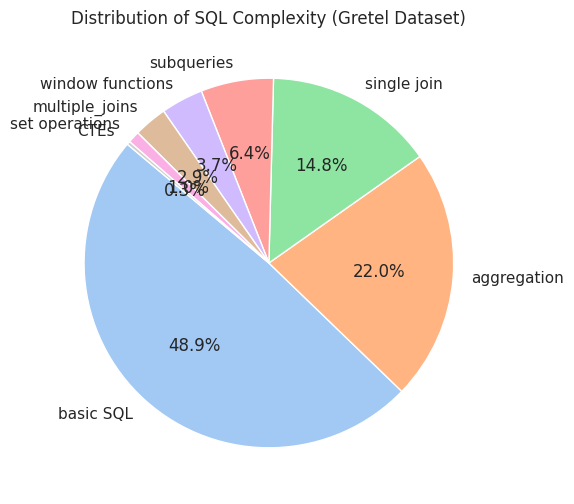

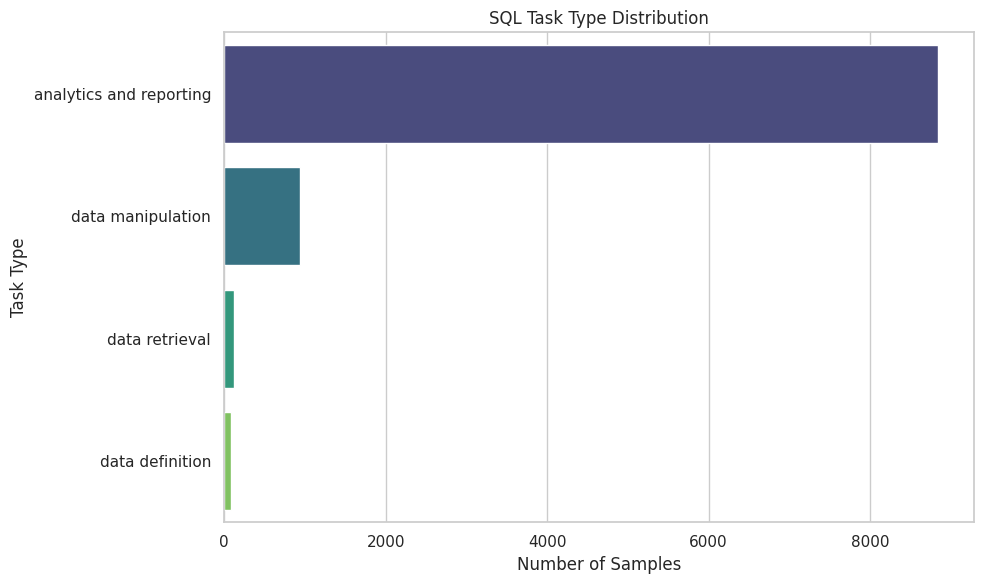

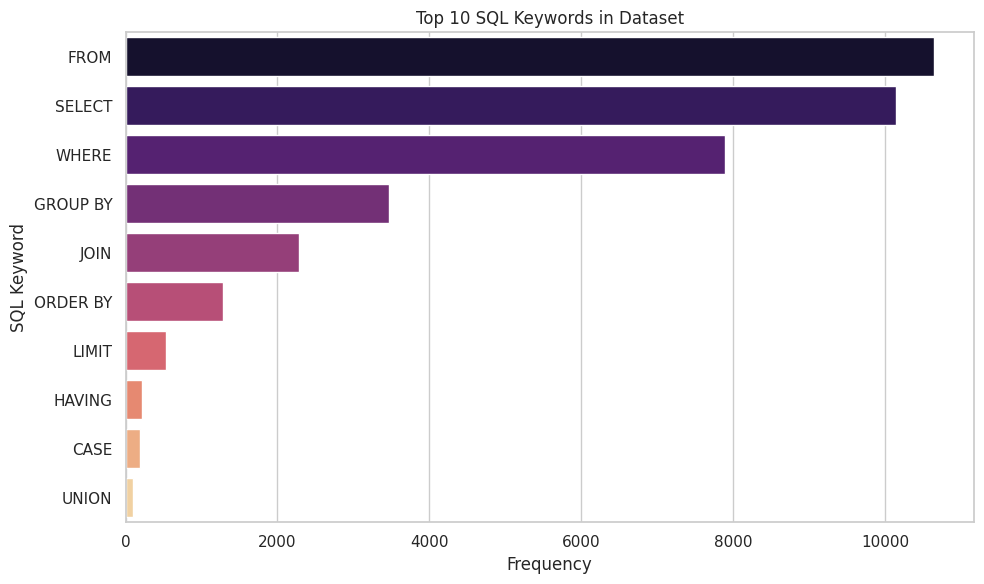

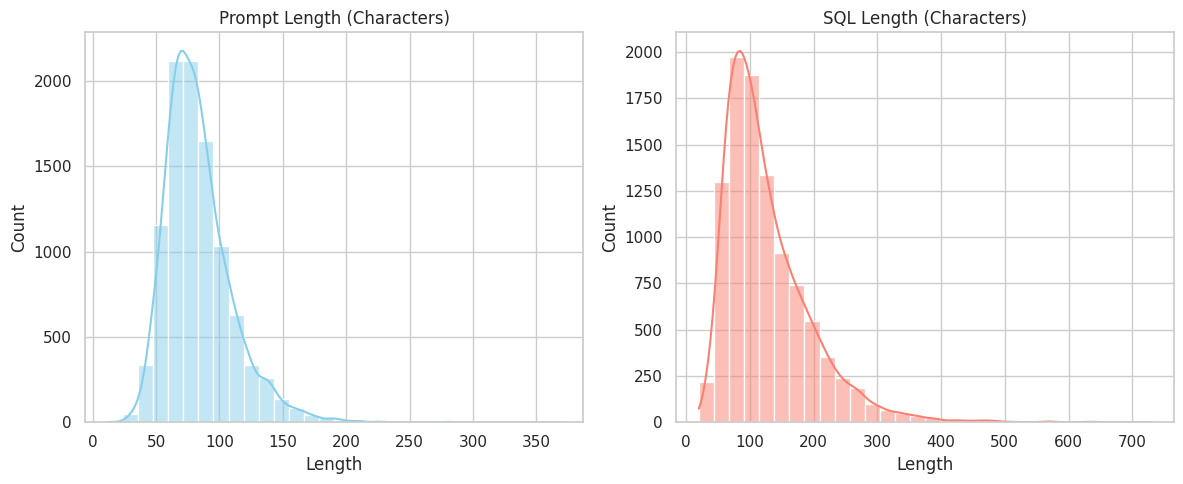

In [ ]:
# Assuming 'train_data' is your dataset object from:
# train_data = load_dataset("gretelai/synthetic_text_to_sql", split="train").select(range(10000))
# Create DataFrame from raw_subset to retain original columns for analysis
df = raw_subset.to_pandas()

# Set the visualization style
sns.set_theme(style="whitegrid")

# 1. SQL Complexity Distribution
plt.figure(figsize=(8, 6))
df['sql_complexity'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=140
)
plt.title('Distribution of SQL Complexity (Gretel Dataset)')
plt.ylabel('')
plt.savefig('sql_complexity_pie.png')

# 2. SQL Task Type Distribution
plt.figure(figsize=(10, 6))
task_order = df['sql_task_type'].value_counts().index
sns.countplot(data=df, y='sql_task_type', order=task_order, palette='viridis')
plt.title('SQL Task Type Distribution')
plt.xlabel('Number of Samples')
plt.ylabel('Task Type')
plt.tight_layout()
plt.savefig('task_type_bar.png')

# 3. SQL Keyword Frequency (Top 10)
def get_keywords(sql_list):
    keywords = []
    for sql in sql_list:
        # Regex to find major SQL keywords
        found = re.findall(r'\b(SELECT|FROM|JOIN|WHERE|GROUP BY|ORDER BY|LIMIT|CASE|CAST|UNION|WITH|HAVING)\b', sql.upper())
        keywords.extend(found)
    return Counter(keywords)

kw_counts = get_keywords(df['sql'].tolist())
kw_df = pd.DataFrame(kw_counts.items(), columns=['Keyword', 'Frequency']).sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=kw_df.head(10), x='Frequency', y='Keyword', palette='magma')
plt.title('Top 10 SQL Keywords in Dataset')
plt.xlabel('Frequency')
plt.ylabel('SQL Keyword')
plt.tight_layout()
plt.savefig('keyword_frequency.png')

# 4. Prompt vs SQL Length Distribution
df['prompt_len'] = df['sql_prompt'].apply(len)
df['sql_len'] = df['sql'].apply(len)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['prompt_len'], bins=30, color='skyblue', kde=True)
plt.title('Prompt Length (Characters)')
plt.xlabel('Length')

plt.subplot(1, 2, 2)
sns.histplot(df['sql_len'], bins=30, color='salmon', kde=True)
plt.title('SQL Length (Characters)')
plt.xlabel('Length')

plt.tight_layout()
plt.savefig('length_distribution.png')

# Show all plots
plt.show()